In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

plt.rcParams.update({'axes.linewidth' : 1.5,
                     'ytick.major.width' : 1.5,
                     'ytick.minor.width' : 1.5,
                     'xtick.major.width' : 1.5,
                     'xtick.minor.width' : 1.5,
                     'xtick.labelsize': 12, 
                     'ytick.labelsize': 12,
                     'axes.labelsize': 18,
                     'axes.labelpad' : 5,
                     'axes.titlesize' : 20,
                     'axes.titlepad' : 10,
                     'font.family': 'Serif'
                    })

mpl.rcParams['mathtext.fontset'] = 'cm'          # Computer Modern serif
mpl.rcParams['mathtext.rm'] = 'serif'

In [23]:
from astropy.io import fits 
from astropy.wcs import WCS

file = "/scratch11/ktp9/TESS_SolarSystem/Neptune/hst/MAST_2025-06-30T05_37_39.155Z/HST/flt/UVIS2 F763M/ieaq28lcq_flt.fits"
with fits.open(file) as hdul:
    sci_header = hdul[1].header
    main_header = hdul[0].header
    data = hdul[1].data
    fits.info(file)
    wcs = WCS(hdul[1].header, hdul)

#print(wcs)

Filename: /scratch11/ktp9/TESS_SolarSystem/Neptune/hst/MAST_2025-06-30T05_37_39.155Z/HST/flt/UVIS2 F763M/ieaq28lcq_flt.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     300   ()      
  1  SCI           1 ImageHDU       212   (512, 512)   float32   
  2  ERR           1 ImageHDU        48   (512, 512)   float32   
  3  DQ            1 ImageHDU        40   (512, 512)   int16   
  4  D2IMARR       1 ImageHDU        16   (64, 32)   float32   
  5  D2IMARR       2 ImageHDU        16   (64, 32)   float32   
  6  WCSDVARR      1 ImageHDU        16   (64, 32)   float32   
  7  WCSDVARR      2 ImageHDU        16   (64, 32)   float32   
  8  HDRLET        1 NonstandardExtHDU     21   (57600,)      
  9  WCSCORR       1 BinTableHDU     59   7R x 24C   [40A, I, A, 24A, 24A, 24A, 24A, D, D, D, D, D, D, D, D, 24A, 24A, D, D, D, D, J, 40A, 128A]   
 10  HDRLET       10 NonstandardExtHDU     21   (57600,)      


In [3]:
print(sci_header)

XTENSION= 'IMAGE   '           / IMAGE extension                                BITPIX  =                  -32 / number of bits per data pixel                  NAXIS   =                    2 / number of data axes                            NAXIS1  =                  512 / length of data axis 1                          NAXIS2  =                  512 / length of data axis 2                          PCOUNT  =                    0 / required keyword; must = 0                     GCOUNT  =                    1 / required keyword; must = 1                     ORIGIN  = 'HSTIO/CFITSIO March 2010' / FITS file originator                     DATE    = '2025-04-04' / date this file was written (yyyy-mm-dd)                INHERIT =                    T / inherit the primary header                     EXTNAME = 'SCI     '           / extension name                                 EXTVER  =                    1 / extension version number                       ROOTNAME= 'ieaq28lcq                    

In [4]:
print(main_header)

SIMPLE  =                    T / file does conform to FITS standard             BITPIX  =                   16 / number of bits per data pixel                  NAXIS   =                    0 / number of data axes                            EXTEND  =                    T / FITS dataset may contain extensions            COMMENT   FITS (Flexible Image Transport System) format is defined in 'AstronomyCOMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H ORIGIN  = 'HSTIO/CFITSIO March 2010' / FITS file originator                     DATE    = '2025-04-04' / date this file was written (yyyy-mm-dd)                NEXTEND =                   10 / Number of standard extensions                  FILENAME= 'ieaq28lcq_flt.fits' / name of file                                   FILETYPE= 'SCI      '          / type of data found in data file                                                                                                TELESCOP= 'HST'                / telesco

In [3]:
print("MAIN HEADER")
print("ra (deg, j2000):", main_header["RA_TARG"])
print("dec (deg, j2000):", main_header["DEC_TARG"])
print("date_obs (mjd):", np.mean([main_header["EXPSTART"], main_header["EXPEND"]]))
print("position angle of v3 axis (deg):", main_header["PA_V3"])

print("SCI HEADER")
print("pos. angle of y-axis (deg east of north)", sci_header["ORIENTAT"])
print("wcs ra, dec:", sci_header["CRVAL1"], sci_header["CRVAL2"])
print("wcs pixel center:", sci_header["CRPIX1"], sci_header["CRPIX2"])

MAIN HEADER
ra (deg, j2000): 352.8022261976
dec (deg, j2000): -4.381915035211
date_obs (mjd): 59464.88408987
position angle of v3 axis (deg): 71.999634
SCI HEADER
pos. angle of y-axis (deg east of north) 116.701682287335
wcs ra, dec: 352.8022262076 -4.381914965211
wcs pixel center: 257.0 255.0


In [11]:
from telescope_reduction import *

In [12]:
folder = "/scratch11/ktp9/TESS_SolarSystem/Neptune/hst/MAST_2025-06-30T05_37_39.155Z/HST/flt/UVIS2 F845M"
hst_list = fits_to_list(folder, "EXPSTART", "RA_TARG", "DEC_TARG", "ORIENTAT", alt_header=1)

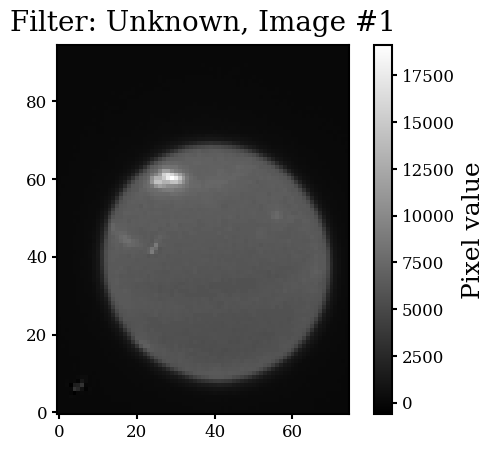

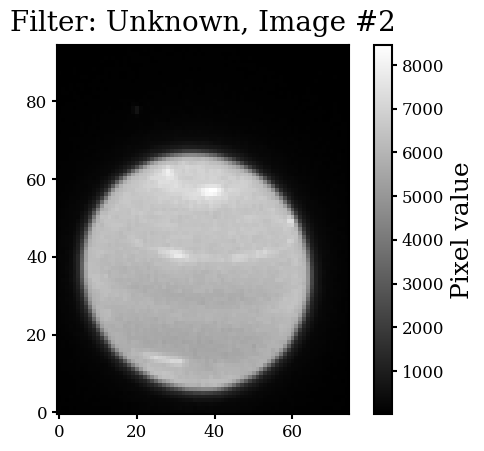

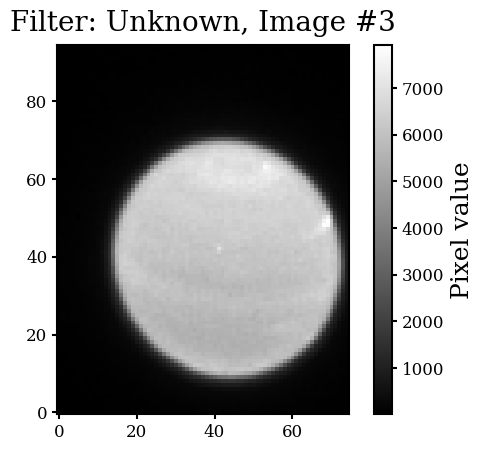

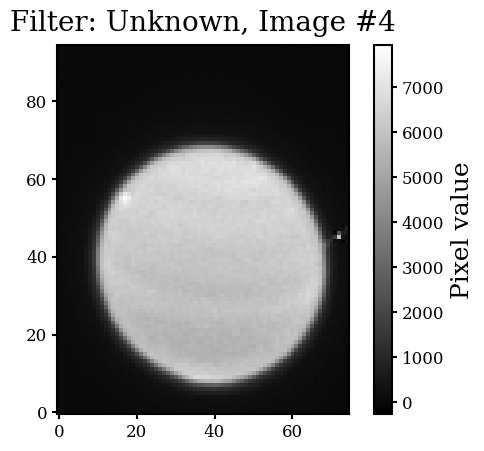

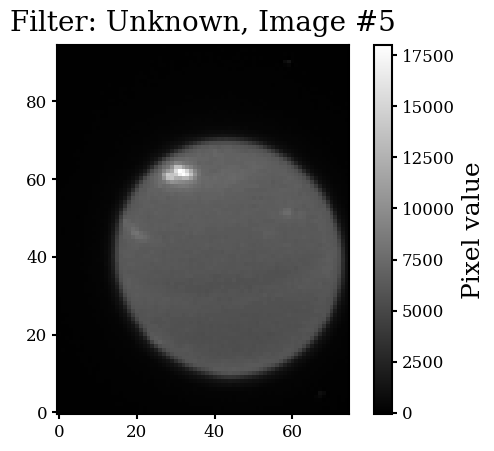

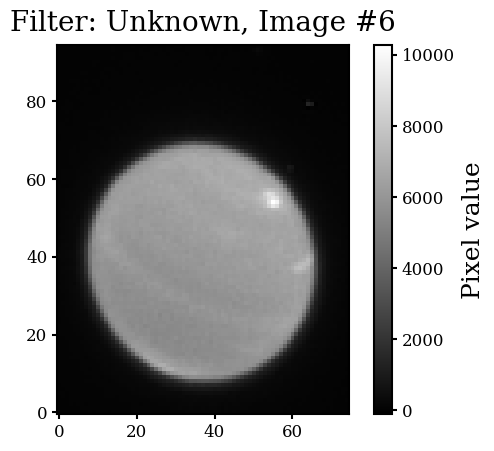

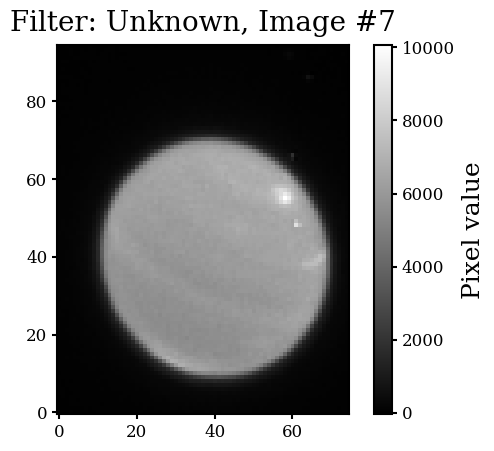

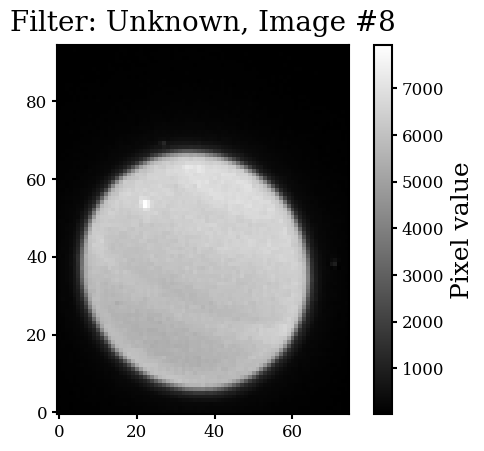

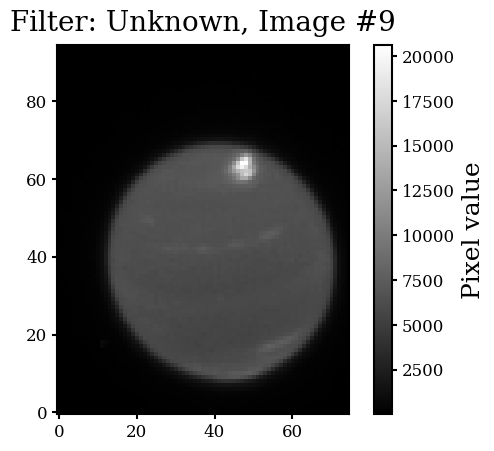

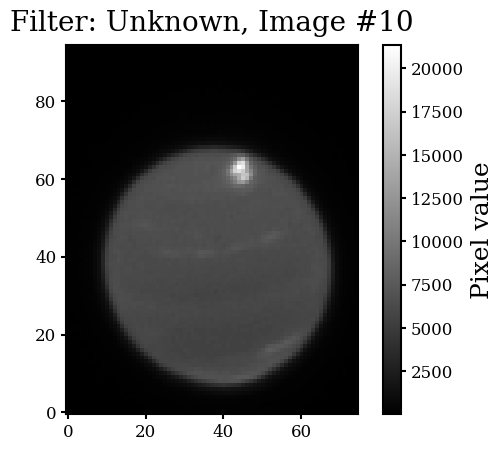

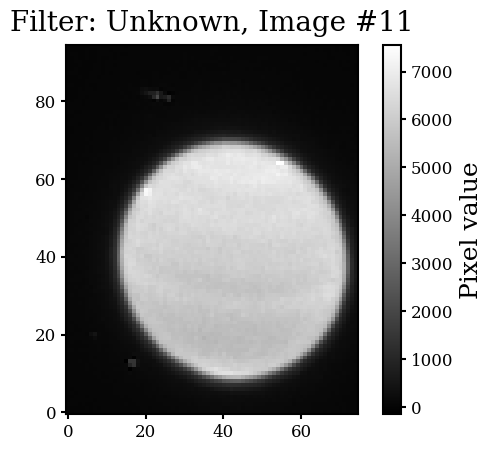

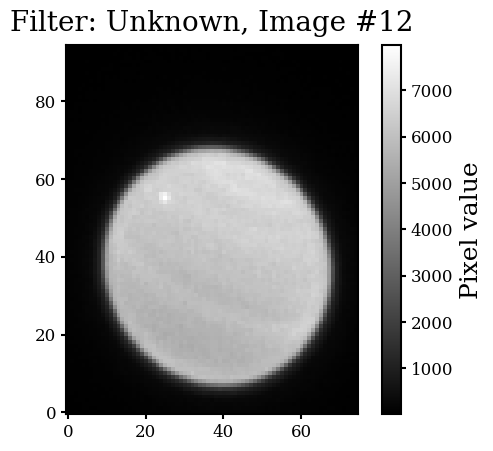

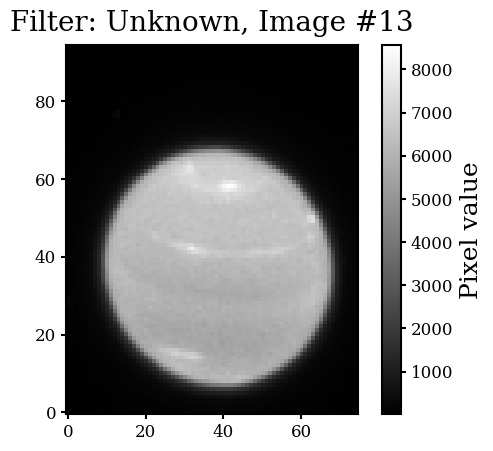

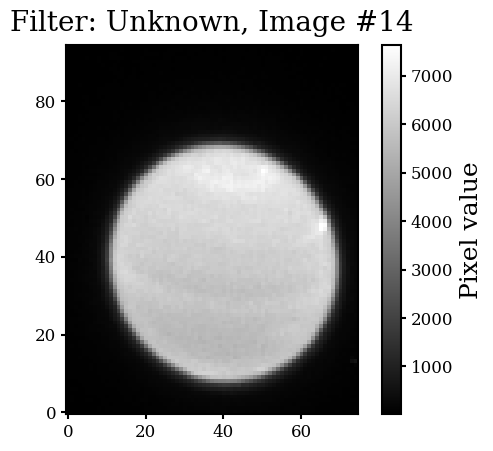

[[40.38801149 38.37580761]]


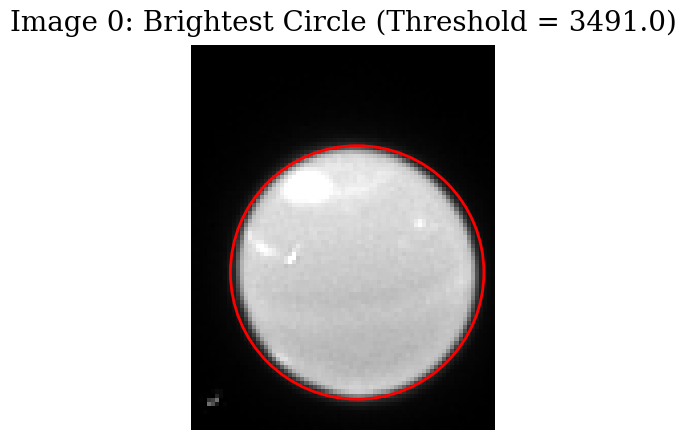

[[35.37110075 36.01972033]]


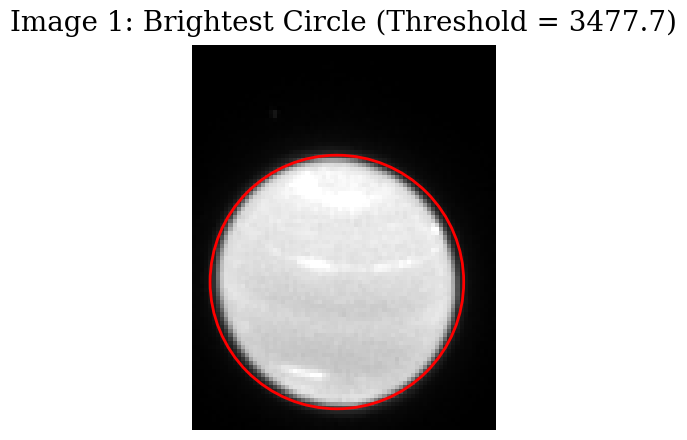

[[43.38676208 39.35563506]]


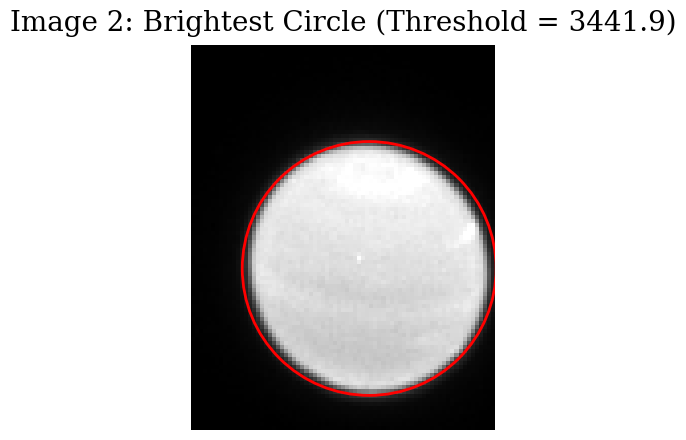

[[39.124197   37.92255532]]


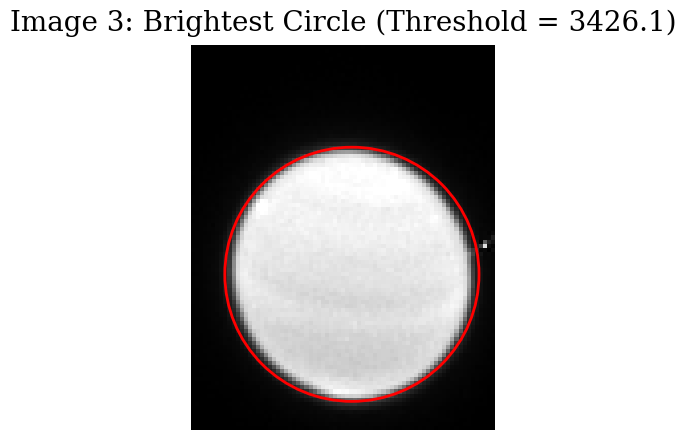

[[43.6408046  39.51724138]]


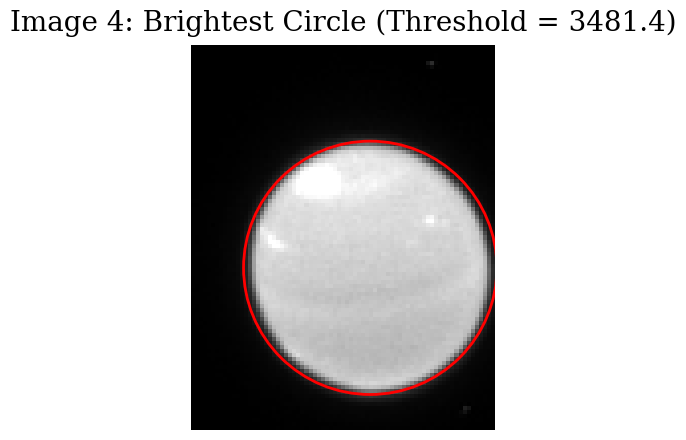

[[36.63633106 38.48513078]]


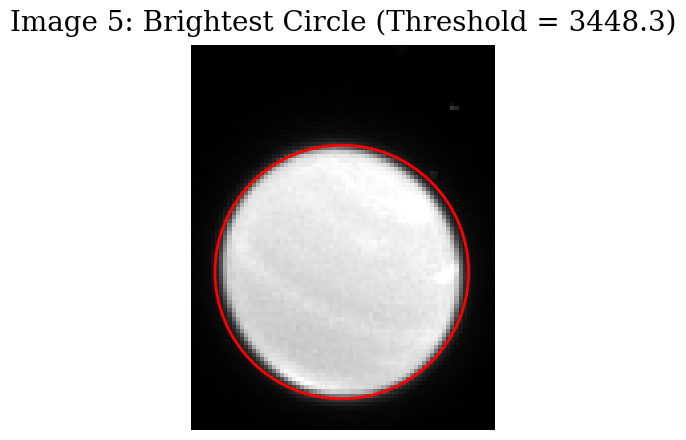

[[40.02646638 39.55686695]]


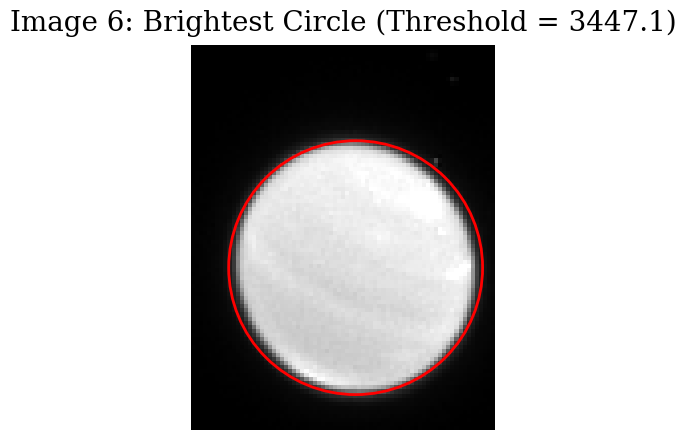

[[35.07455197 36.26774194]]


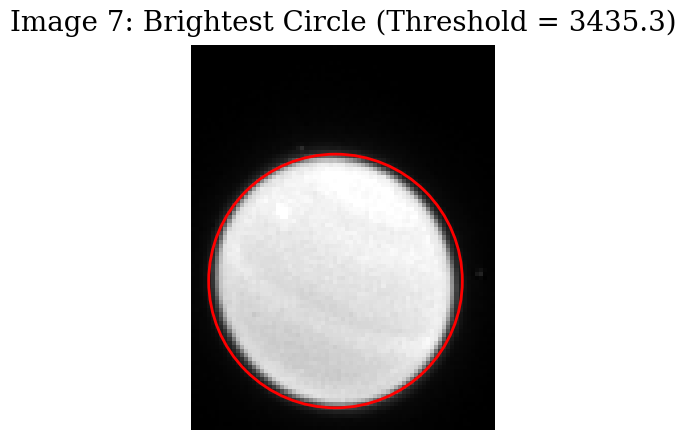

[[41.69164575 38.59842237]]


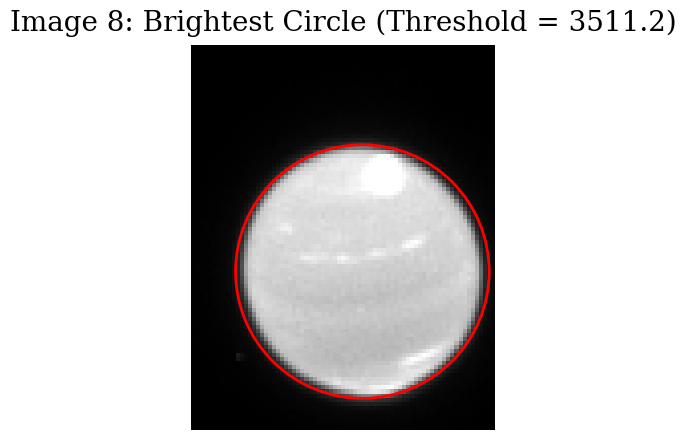

[[38.43741059 37.45851216]]


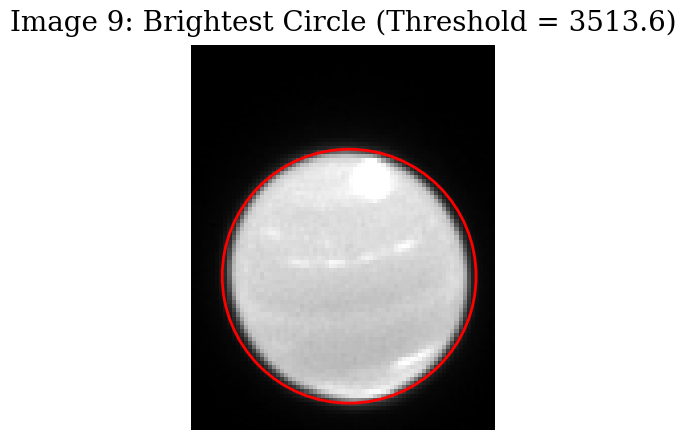

[[42.46365915 39.02184032]]


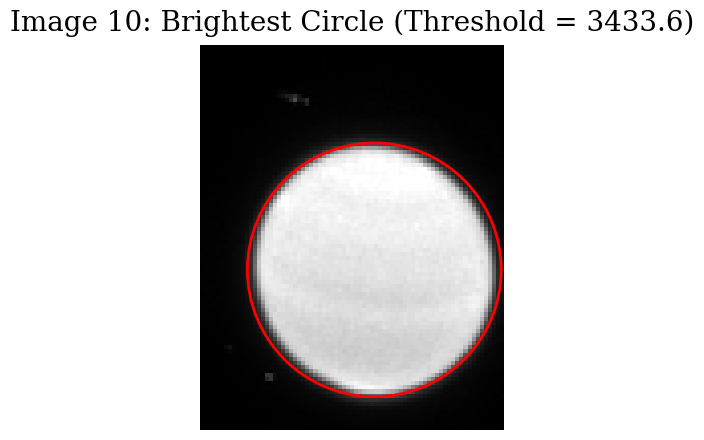

[[38.43077475 37.28586801]]


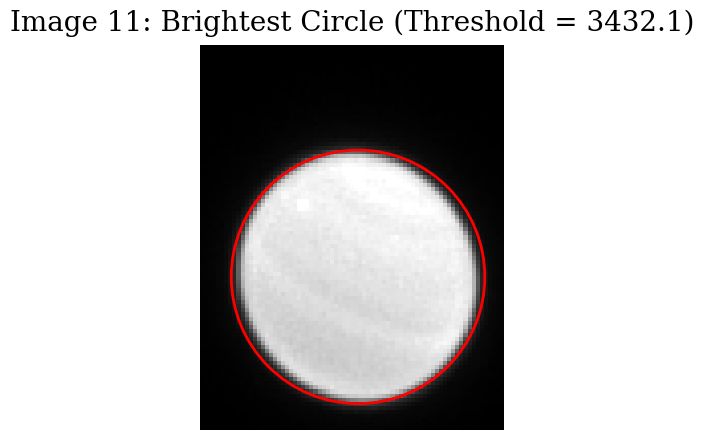

[[38.54617037 37.1678597 ]]


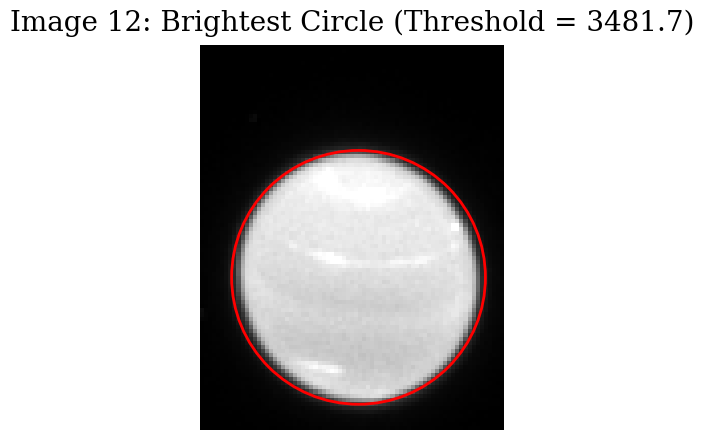

[[40.01322846 38.29674651]]


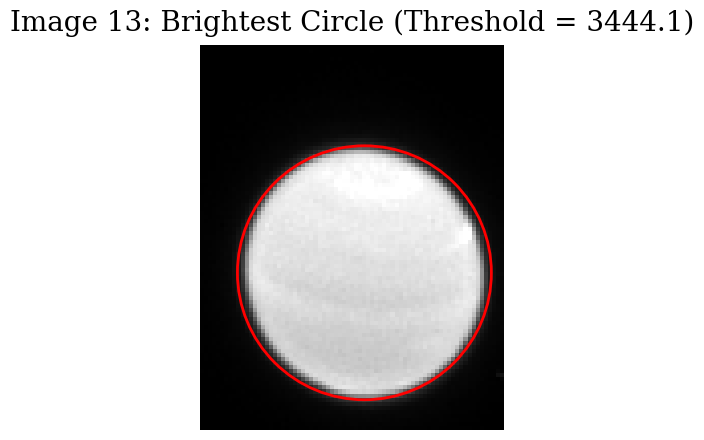

In [33]:
hst_images = [entry['data'] for entry in hst_list]

rotated_images = [rotate_image(img) for img in hst_images]

cropped_images = [img[row_start:row_end, col_start:col_end] for img in rotated_images]

show_image_list(cropped_images)

results = draw_largest_bright_circle(cropped_images, use_adaptive_threshold=True,
                                percentile_threshold=95,
                                radius_scale=1.05, show=True)

In [41]:
from astropy.coordinates import SkyCoord
import astropy.units as u

def find_celestial_north(data, wcs):
    ny, nx = data.shape
    center = wcs.pixel_to_world(nx // 2, ny // 2)

    # Move a small amount north in Dec (e.g., 0.1 deg)
    celestial_north = SkyCoord(ra=center.ra, dec=center.dec + 0.1 * u.deg, frame='icrs')

    angle_to_north = center.position_angle(celestial_north)

    return angle_to_north


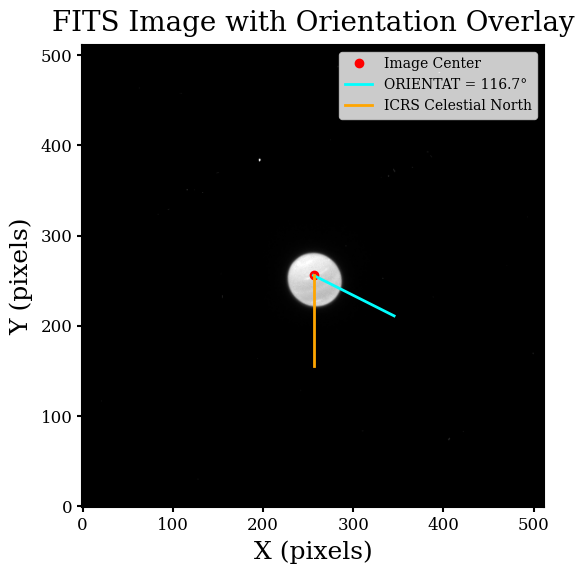

In [43]:
ny, nx = data.shape
x0, y0 = nx // 2, ny // 2  # image center

angle_deg = sci_header["ORIENTAT"]
angle_rad = np.deg2rad(angle_deg)
nep_inclination = np.deg2rad(28.3)
orbit_inclination = np.deg2rad(1.77)

plt.figure(figsize=(6,6))
plt.imshow(data, origin='lower', cmap='gray', vmin=np.percentile(data, 50), vmax=np.percentile(data, 99.99))

# Plot image center
plt.plot(x0, y0, 'ro', label="Image Center")

# Plot a line showing ORIENTAT direction
length = 100  # pixels
x1 = x0 + length * np.sin(angle_rad)
y1 = y0 + length * np.cos(angle_rad)
plt.plot([x0, x1], [y0, y1], color='cyan', lw=2, label=f"ORIENTAT = {angle_deg:.1f}°")

# x2 = x0 + length * np.sin(angle_rad + nep_inclination)
# y2 = y0 + length * np.cos(angle_rad + nep_inclination)
# plt.plot([x0, x2], [y0, y2], color='orange', lw=2, label=f"ORIENTAT & Inclination")

# x3 = x0 + length * np.sin(angle_rad + nep_inclination + orbit_inclination)
# y3 = y0 + length * np.cos(angle_rad + nep_inclination + orbit_inclination)
# plt.plot([x0, x3], [y0, y3], color='magenta', lw=2, label=f"ORIENTAT, Inclination, Orb.")

plt.title("FITS Image with Orientation Overlay")
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.grid(False)


from scipy.ndimage import rotate

angle_to_ecliptic_north = find_celestial_north(data, wcs)
length = 100  # pixels
dx = length * np.sin(angle_to_ecliptic_north.radian)
dy = length * np.cos(angle_to_ecliptic_north.radian)

x0, y0 = nx // 2, ny // 2
plt.plot([x0, x0 - dx], [y0, y0 - dy], color='orange', lw=2, label="ICRS Celestial North")
plt.legend()

plt.show()

# rotated_image = rotate(data, angle_rad, reshape=False, order=3)

# plt.imshow(rotated_image, cmap='gray', vmin=0, vmax=np.percentile(rotated_image, 99.99))
# plt.title("Image Aligned with Ecliptic North")
# plt.show()


In [40]:
print(np.degrees(angle_to_ecliptic_north))

from astropy.coordinates import Angle

angle = Angle(angle_to_ecliptic_north)
print(angle.degree)


336d45m11.03149842s
336.7530643051167


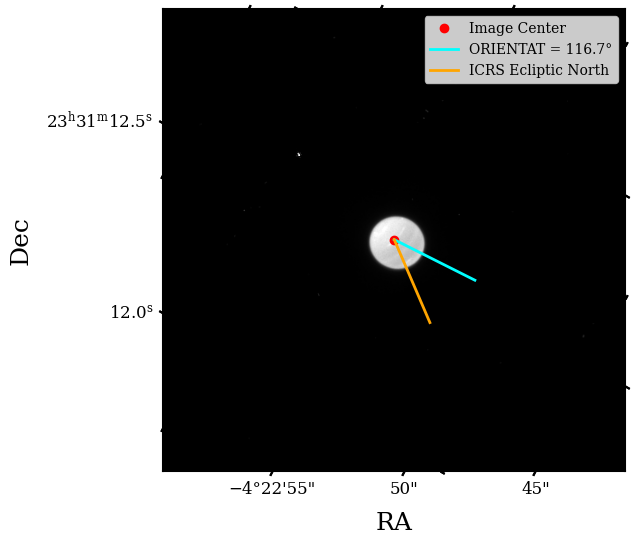

In [39]:
from astropy.wcs import WCS

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection=wcs)
rotated_image = rotate(data, angle.degree, reshape=False, order=3)

plt.imshow(rotated_image, origin='lower', cmap='gray', vmin=np.percentile(data, 50), vmax=np.percentile(data, 99.99))
plt.plot(x0, y0, 'ro', label="Image Center")
plt.plot([x0, x1], [y0, y1], color='cyan', lw=2, label=f"ORIENTAT = {angle_deg:.1f}°")
plt.plot([x0, x0 - dx], [y0, y0 - dy], color='orange', lw=2, label="ICRS Ecliptic North")
plt.xlabel("RA")
plt.ylabel("Dec")
plt.legend()
plt.show()


In [ ]:
def rotate_to_planet_frame(imglist, orbit_inclination=0, axial_tilt=0, show=False, vmin=None, vmax_percentile=None):
    """
    Loops through every image in an imagelist and returns the data rotates according to "orientat" and planet parameters
    """
    
    data_list = [entry['data'] for entry in imglist]
    orient_list = [entry['orientat'] for entry in imglist]

    for data in data_list:
        angle_adjustment = 

        with fits.open(file_path) as hdul:
            data = hdul[data_hdu].data
            header = hdul[header_hdu].header
            
            print(f"/.n--- {fname} ---")
            
            plt.figure()
            if vmin is not None:
                plt.imshow(data, origin='lower', cmap='gray', vmin=vmin, vmax=np.percentile(data, vmax_percentile))
            else:
                plt.imshow(data, origin='lower', cmap='gray')#, vmin=0, vmax=np.percentile(data, 99.99))
            plt.title(fname)
            plt.colorbar(label='Pixel value')
            plt.show()